In [111]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [138]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.4]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))
                    

In [148]:
tol = 1e-24

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

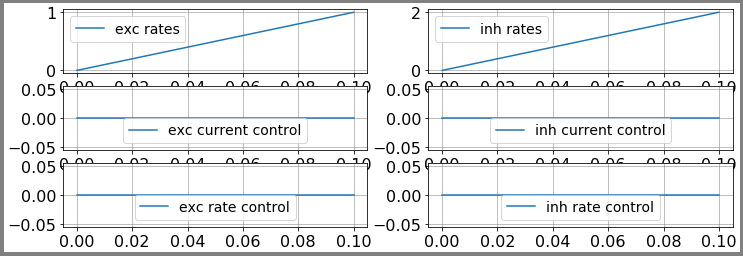

In [400]:
aln = RateModel()

aln.params['duration'] = 0.1
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.4
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

setParametersALN(aln)

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

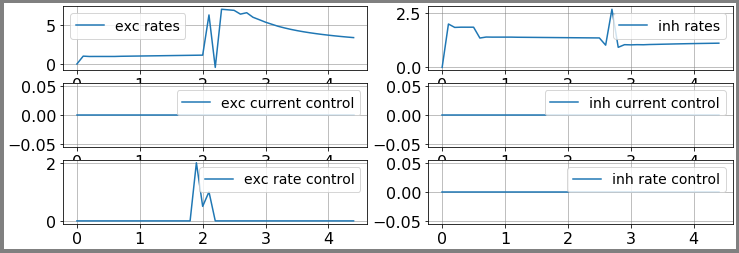

delay : 
sigma e  [[ 1.          0.95610184  0.95940289  0.95918128  0.95919628  0.95919527
   0.98204205  0.99252965  1.00401502  1.01526314  1.02638673  1.0373544
   1.04858464  1.05971371  1.0708407   1.08194668  1.09302917  1.10408271
   1.11511024  1.12610577  6.24297968 -0.43392593  6.96494905  6.89570472
   6.82674352  6.3467613   6.52553237  5.94678311  5.63574818  5.317828
   5.05548649  4.79764682  4.59217597  4.40871653  4.24844842  4.10576887
   3.97920146  3.86479178  3.7611403   3.66656795  3.57988829  3.50005039
   3.4262657   3.35783544 26.40984752]]


In [412]:
setinitvars(high_state_vars)

dur = 3.4
dur_pre = 1.
dur_post = 1.

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 15.
    min_cntrl = -15.
else:
    max_cntrl = 5.#0.5
    min_cntrl = -5.#0.5

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 8] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 9] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 10] = 0.2 * max_cntrl #+ 0.3 * min_cntrl
    #control0[0,j,n_pre + 6] = 0.2 * max_cntrl #- 0.6 * min_cntrl
    #control0[0,j,n_pre + 7] = 0.2 * max_cntrl + 0.8 * min_cntrl

plotFunc.plot_traces(aln, control0)
print("delay : ")
#print("exc rates : ", aln.rates_exc[0,:])
#print("inh rates : ", aln.rates_inh[0,:])
print("sigma e ", aln.state["sigmae_f"])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-2):
    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [423]:
costparams = [1. * 1e0, 1.* 1e-0, 1.* 1e-0]
#costparams = [90, 0.001, 0.002]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 2000
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 0.6
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control2, target,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0023455659049372796
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind[0],:] ) ) )

set cost params
RUN  0 , total integrated cost =  1.2421736165872788
RUN  1 , total integrated cost =  1.242173616587244
RUN  2 , total integrated cost =  1.2421736165872121
RUN  3 , total integrated cost =  1.2421736165871815
RUN  4 , total integrated cost =  1.242173616587159
RUN  5 , total integrated cost =  1.2421736165871364
RUN  6 , total integrated cost =  1.2421736165871136
RUN  7 , total integrated cost =  1.242173616587093
RUN  8 , total integrated cost =  1.2421736165870678
RUN  9 , total integrated cost =  1.2421736165870407
RUN  10 , total integrated cost =  1.2421736165870163
RUN  11 , total integrated cost =  1.2421736165869932
RUN  12 , total integrated cost =  1.242173616586972
RUN  13 , total integrated cost =  1.2421736165869501
RUN  14 , total integrated cost =  1.2421736165869266
RUN  15 , total integrated cost =  1.2421736165869057
RUN  16 , total integrated cost =  1.2421736165868729
RUN  17 , total integrated cost =  1.2421736165868393
RUN  18 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  1.2421736165670585
RUN  2000 , total integrated cost =  1.2421736165670585
Improved over  2000  iterations by  1.627810775062244e-09  percent.
Problem in initial value trasfer:  sigmae_f 2.537247331620093 1.0263867292249345
Problem in initial value trasfer:  sigmae_f 26.409843900433724 3.2941833029757026
control ind  2
grad =  [ 4.78087541e-07 -2.01197132e-06 -2.02503240e-06  5.33704100e-07
  4.60136742e-06 -4.41720302e-06 -2.28839238e-06 -2.75786504e-06
  6.82543872e-06  2.26685163e-06 -2.03386177e-06  4.93252243e-06
 -7.52419232e-07 -4.78202442e-07 -3.31086034e-07 -3.30845262e-07
 -2.33401069e-07 -2.17460183e-07 -1.75304078e-07 -1.44528230e-07
 -1.13378814e-07 -1.04292455e-07 -6.96388009e-08 -6.78521532e-08
 -8.25975824e-08  5.52865500e-08 -2.46177942e-07  2.58849003e-07
 -1.78164151e-07 -4.20982671e-07  1.50210088e-06 -2.63968238e-06
  2.33435342e-06  0.00000000e+00  0.00000000e+00]
best control =  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00

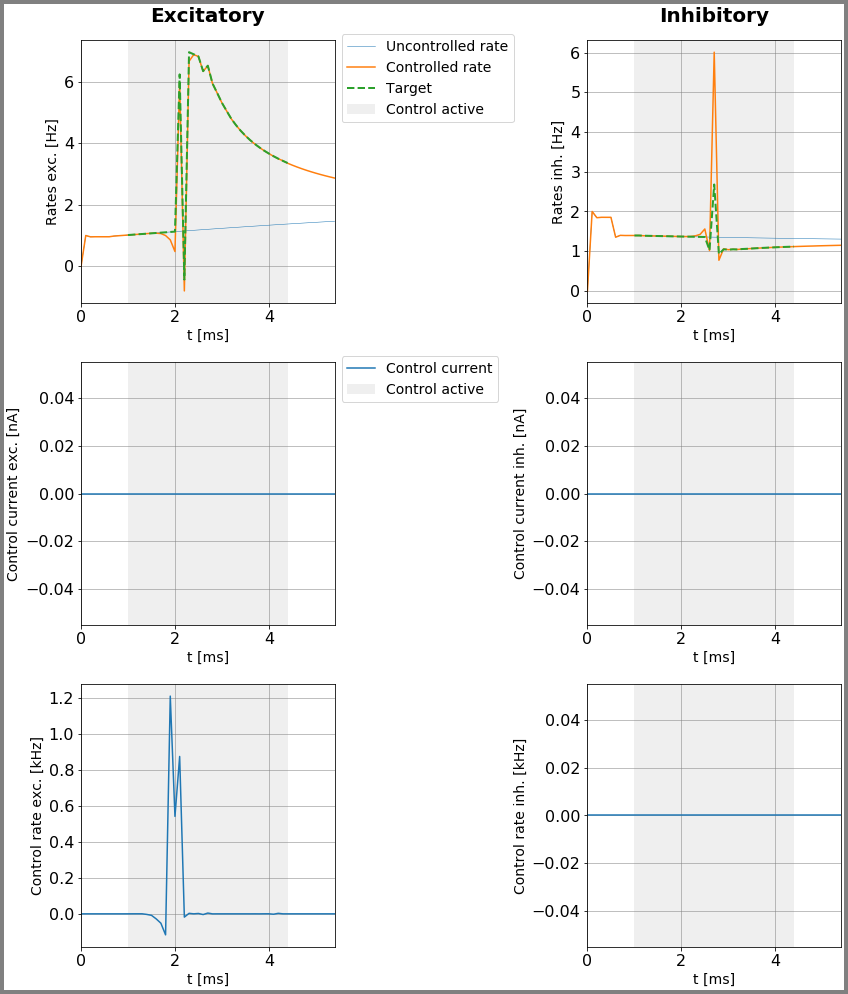

In [420]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [405]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_pre+1]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0],:])

ERROR:root:not implemented for less than full timesteps
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost:  0.6516586939592408
Control only changes marginally.
RUN  1 , total integrated cost:  0.6516586939592408
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 2.537247331620093 1.0263867292249345
Problem in initial value trasfer:  sigmae_f 29.977573263425565 3.614253013843874
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -5.69588738e-03  2.62752375e-03
 -2.35380886e-02 -6.08947334e-02 -2.15279652e-01  1.02076509e+00
  5.62728006e-01  8.49841726e-01 -1.63350113e-02  4.91737514e-03
  1.39773889e-04  3.43136331e-03  2.54573447e-02 -3.63565845e-02
  1.04333513e-02 -4.96782187e-04  6.78889157e-05 -8.76803268e-05
  8.18211005e-05 -3.13646982e-05  5.02945527e-06 -4.73305401e-07
  4.32429423e-07 -3.71275423e-07  1.22047666e-07  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.0

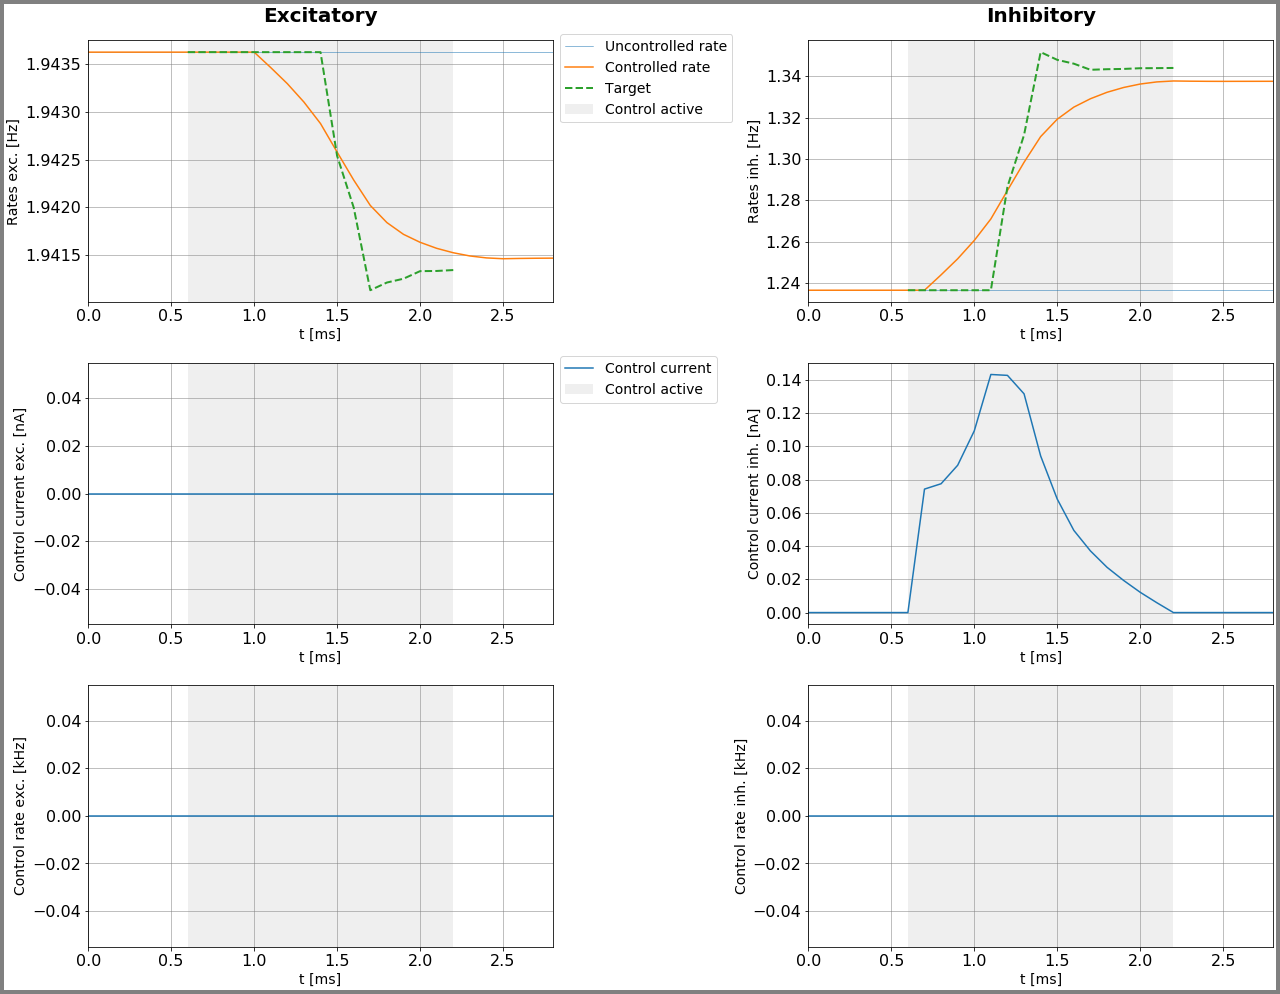

In [1511]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

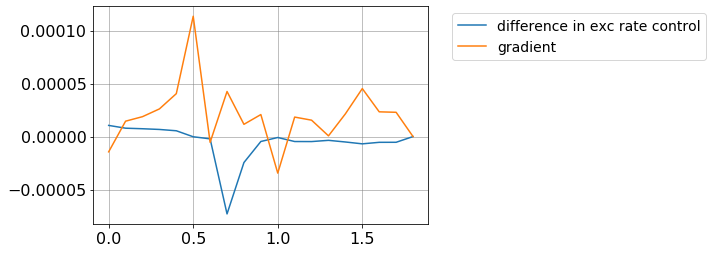

In [1219]:
diff = bestControlA_A2 - bestControlA
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc current control")
#plt.plot(t, diff[0,1,:], label="difference in inh current control")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid()
#plt.show()

plt.plot(t, diff[0,2,n_pre-1:-n_post+1], label="difference in exc rate control")
#plt.plot(t, diff[0,3,n_pre:-n_post], label="difference in inh rate control")
plt.plot(t, grad[0,2,:], label="gradient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.

### What to take into account and don't forget
- if delay is present, always leave sufficient time steps before and after applying control
- allowing rates smaller than zero may cause trouble, because then same input can have different effect at different points of time
- is the fact that control enters computation at various points causing problems?
- if stuff of different orders of magnitude is competing, convergence is slow
- convergence in integration variables is much slower than in direct input
- make sure variables are in proper range: setting e.g. sigma to zero in time integration can cause problems
- the dynamics should not be explicitly dependent on time, otherwise adjoint formulation does not hold in this way
- apparently, also time-independent contributions mess up wiht the algorithm